# Solution of the IPT-DMFT equations using the Discrete Lehman Representation

This example is similar to Tutorial 1 in the ModelDMFT folder, but uses the discrete Lehmann representation (DLR) to represent the Green's functions and self-energies. Try repeating Tutorial 1 to converge the IPT equations for a given $\beta$ and $U$. Check how much quicker your calculations are compared to Tutorial 1. Then obtain a Padé approximation of the spectral function $A(\omega)$. For more information about the IPT equations, [(here)](https://doi.org/10.1103/PhysRevB.86.085133) is a good first reference, which this example follows closely.

In [106]:

from triqs.gf import *
import numpy as np
from triqs.operators import *

class IPTSolver:
    def __init__(self, params):
        self.params = params
        # Matsubara frequency Green's functions
        iw_mesh = MeshDLRImFreq(beta=params["beta"], statistic='Fermion', w_max= params["w_max"], eps =params["dlr_err"], symmetrize = True)
        self.G_iw = BlockGf(mesh=iw_mesh, gf_struct = [('up',1), ('dn',1)] )
        self.G0_iw = self.G_iw.copy() # self.G0 will be set by the user after initialization
        self.Sigma_iw = self.G_iw.copy()

        # Imaginary time
        tau_mesh = MeshDLRImTime(beta=params["beta"], statistic='Fermion', w_max= params["w_max"], eps =params["dlr_err"], symmetrize = True)
        self.G0_tau = BlockGf(mesh=tau_mesh, gf_struct = [('up',1), ('dn',1)] )
        self.G_tau = self.G0_tau.copy()
        self.Sigma_tau = self.G0_tau.copy()

    def solve(self):
        error = 1.0
        iter = 0

In [112]:
params = {
    "beta": 50.0,
    "mu": 0.0,
    "alpha" : 0.5,
    "w_max": 10.0,
    "dlr_err": 1e-8, 
    "U" : 3.0, # In the Mott state, U > 4, you run into trouble, but this is also why the IPT tutorial just stops at small iteration number. 
    "t" : 1.0,
    "max_iter": 1000,
    "threshold": 1e-8,
}

In [113]:
S = IPTSolver(params)
S.G_iw << SemiCircular(2*params["t"])


Green Function G composed of 2 blocks: 
 Greens Function G_up with mesh DLR imfreq mesh of size 36 with beta = 50, statistic = Fermion, w_max = 10, eps = 1e-08 and target_shape (1, 1): 
 
 Greens Function G_dn with mesh DLR imfreq mesh of size 36 with beta = 50, statistic = Fermion, w_max = 10, eps = 1e-08 and target_shape (1, 1): 
 

In [114]:
error = 1.0
iter = 0
while error > params["threshold"]:
    for block, g in S.G0_iw:
        g << inverse( iOmega_n - params["t"]**2 * S.G_iw[block] )
    S.G0_tau << make_gf_dlr_imtime(S.G0_iw)
    S.Sigma_tau << (params["U"]**2) * S.G0_tau * S.G0_tau * S.G0_tau
    S.Sigma_iw << make_gf_dlr_imfreq(S.Sigma_tau)
    G_old = S.G_iw.copy()
    S.G_iw << inverse(inverse(S.G0_iw) - S.Sigma_iw)
    S.G_iw << params["alpha"]*S.G_iw+ (1-params["alpha"])*G_old
    G_tau_old = S.G_tau.copy()
    S.G_tau << make_gf_dlr_imtime(S.G_iw)
    error = np.max(np.abs((S.G_tau["up"].data[:,0,0] - G_tau_old["up"].data[:,0,0])))     # Compute absolute error
    iter += 1

    print("Iteration:", iter, "Error:", error)
    if iter > params["max_iter"]:
        print("Maximum number of iterations reached without convergence")
        break

Iteration: 1 Error: 0.4994691601105864
Iteration: 2 Error: 0.013218442183916101
Iteration: 3 Error: 0.006275825531574575
Iteration: 4 Error: 0.002993884912959155
Iteration: 5 Error: 0.0014307653808706133
Iteration: 6 Error: 0.0006841141729723721
Iteration: 7 Error: 0.00032711102854793284
Iteration: 8 Error: 0.0001563808101129327
Iteration: 9 Error: 7.474213040459254e-05
Iteration: 10 Error: 3.571384048717263e-05
Iteration: 11 Error: 1.719079397405343e-05
Iteration: 12 Error: 8.315824688021056e-06
Iteration: 13 Error: 4.021901271578088e-06
Iteration: 14 Error: 1.9448479028350008e-06
Iteration: 15 Error: 9.403252946849072e-07
Iteration: 16 Error: 4.545876733930143e-07
Iteration: 17 Error: 2.197414414872867e-07
Iteration: 18 Error: 1.0621059087778661e-07
Iteration: 19 Error: 5.1332351869159965e-08
Iteration: 20 Error: 2.4807740583998594e-08
Iteration: 21 Error: 1.1988382841998657e-08
Iteration: 22 Error: 5.7931588970383554e-09


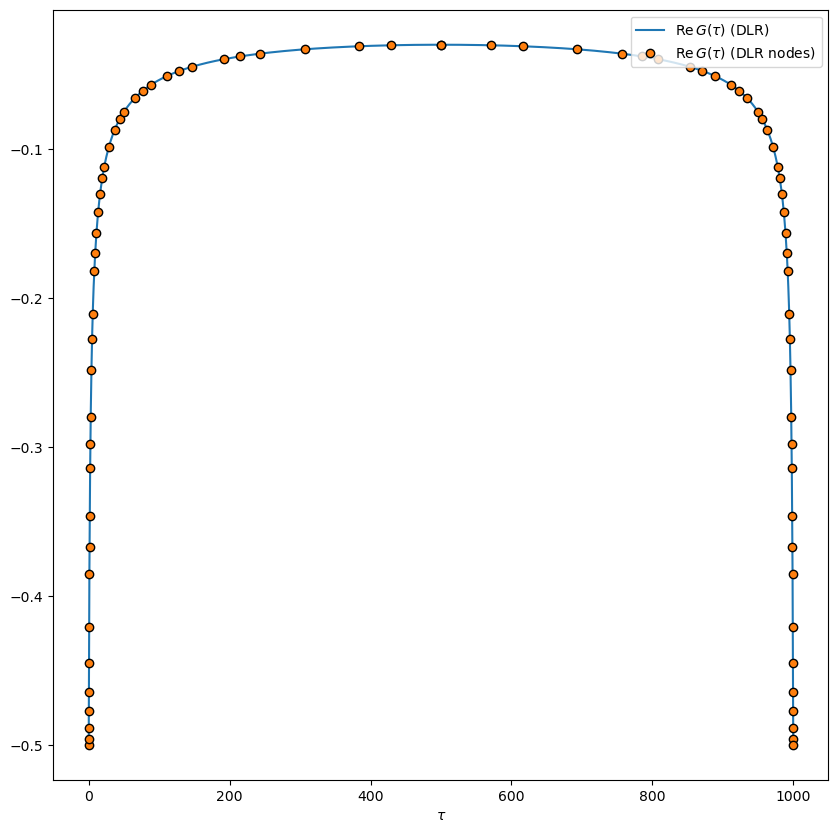

In [116]:
G_tau_dense = make_gf_imtime(G_tau["up"], n_tau=1000)   # Obtain DLR expansion on dense imaginary time grid

plt.figure(figsize = (10,10))
oplot(G_tau_dense.real, label = r"$\mathrm{Re}\, G(\tau)$ (DLR)")
oplot(G_tau["up"].real, marker = "o", markeredgecolor = "black", label = r"$\mathrm{Re}\, G(\tau)$ (DLR nodes)")
plt.ylabel("")
plt.legend(loc="upper right")
plt.show()

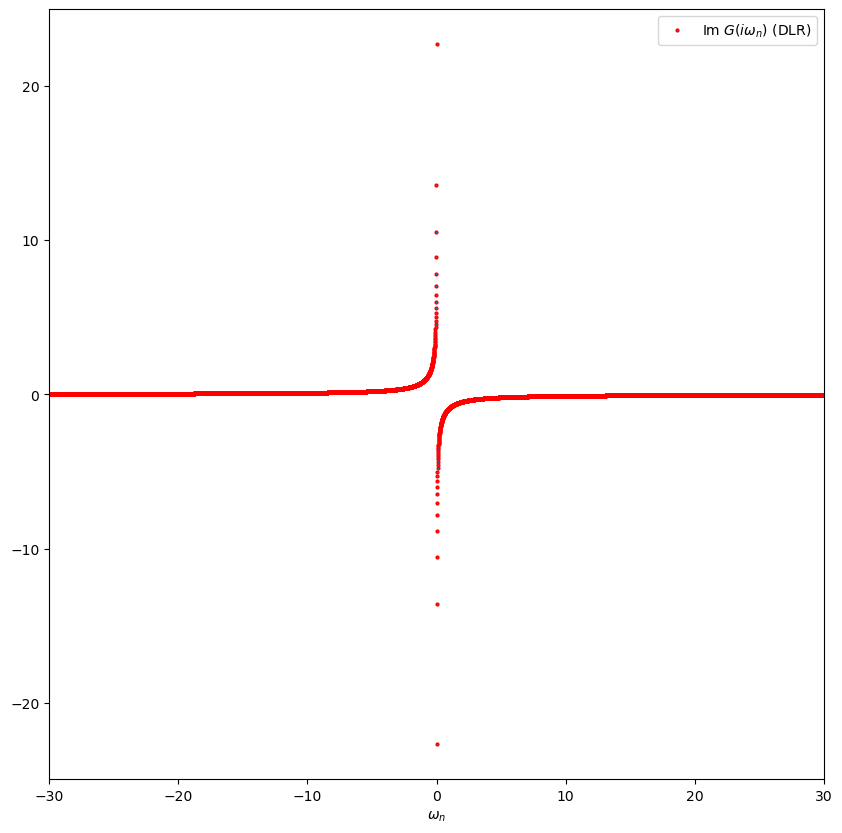

In [121]:
G_iw_dense = make_gf_imfreq(G_iw["up"], n_iw = 5000)    # Obtain DLR expansion on dense Matsubara frequency grid

plt.figure(figsize = (10,10))
oplot(G_iw_dense.imag, marker = "o", markeredgecolor = "red", markersize=2, linestyle="none", label = r"Im $G(i \omega_n)$ (DLR)")
plt.xlim(-30,30)
plt.ylabel("")
plt.show()

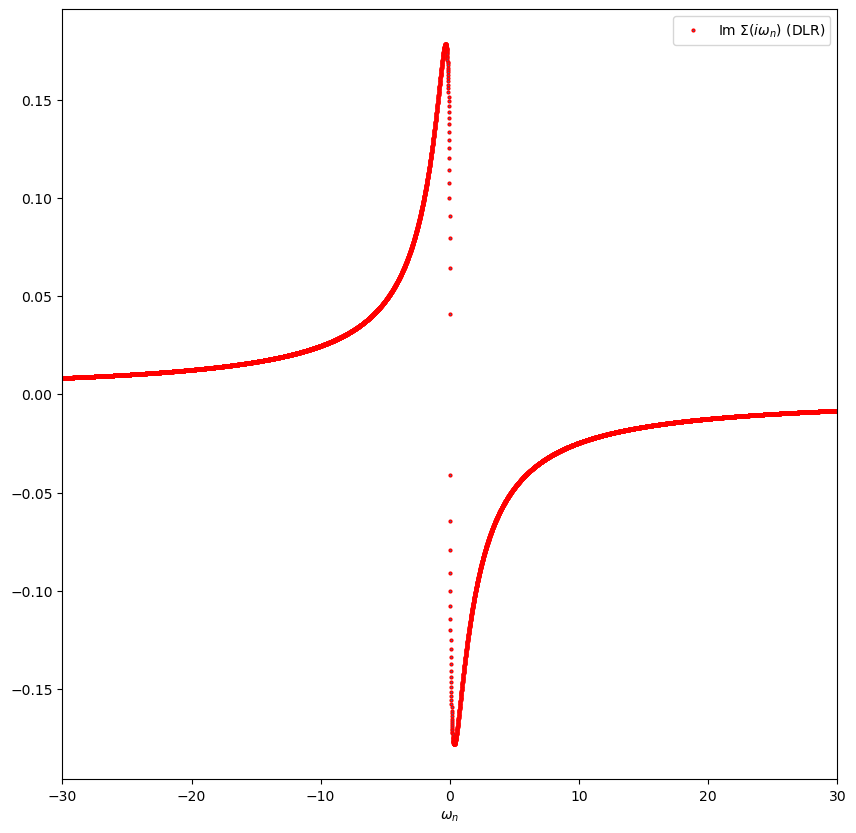

In [122]:
Sigma_iw_dense = make_gf_imfreq(Sigma_iw["up"], n_iw = 5000)    # Obtain DLR expansion of self-energy on dense Matsubara frequency grid

plt.figure(figsize = (10,10))
oplot(Sigma_iw_dense.imag, marker = "o", markeredgecolor = "red", markersize=2, linestyle="none", label = r"Im $\Sigma(i \omega_n)$ (DLR)")
plt.xlim(-30,30)
plt.ylabel("")
plt.show()

In [123]:
G_w = Gf(mesh=MeshReFreq(window = (-5.0,5.0), n_w=1000), target_shape=[1,1])
G_iw = make_gf_imfreq(S.G_iw["up"], n_iw = 2**14+3)
G_w.set_from_pade(G_iw, 100, 0.01)      # Pade analytic continuation

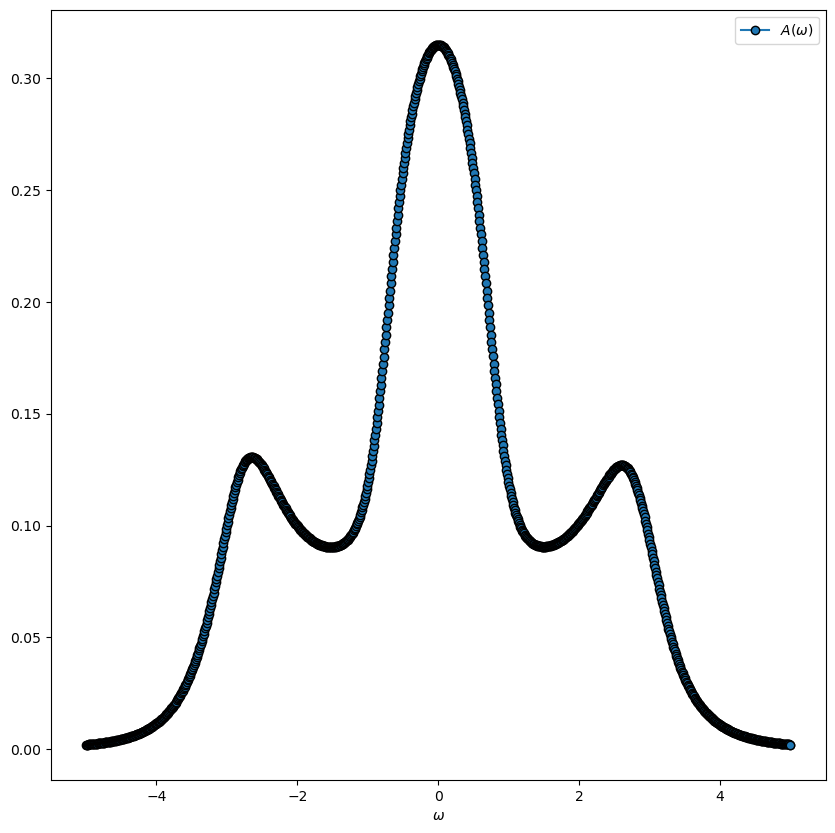

In [124]:
plt.figure(figsize = (10,10))
oplot(-np.imag(G_w)/np.pi, marker = "o", markeredgecolor = "black", label = r"$A(\omega)$")
plt.ylabel("")
plt.show()